# Week 10: Recommendation, Ranking, and Offline Evaluation

This notebook is the Week 10 deliverable for the anime recommendation project. The decision task is personalized anime ranking: given what a user has scored and liked, rank candidate anime that are plausible next discoveries.

The final product is not a single fixed list. It is a recommender with user controls and profile-band-aware behavior. The bands use the requested thresholds: `0/20/50/100/250/500/750`. A Newcomer needs safe entry points and filters; a Completionist needs novelty, long-tail coverage, and graph-aware exploration.

The notebook follows the Week 8-10 course path: content metadata and filters help cold start, collaborative filtering uses the interaction matrix when behavior exists, and the final system compares baselines against a stronger hybrid ranking model.


In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent

ARTIFACT_DIR = BASE_DIR / 'artifacts' / 'recommendation'
PLOT_DIR = BASE_DIR / 'artifacts' / 'plots' / 'week10'
SCRIPT_PATH = BASE_DIR / 'src' / '08_run_week10_recommendation.py'

METRICS_PATH = ARTIFACT_DIR / 'week10_evaluation_metrics.csv'
LEVEL_METRICS_PATH = ARTIFACT_DIR / 'week10_metrics_by_user_level.csv'
SUMMARY_PATH = ARTIFACT_DIR / 'week10_recommendation_summary.json'
EXAMPLES_PATH = ARTIFACT_DIR / 'week10_recommendation_examples.csv'
ALIGNMENT_PATH = ARTIFACT_DIR / 'week10_data_alignment.csv'
USER_EVAL_PATH = ARTIFACT_DIR / 'week10_user_level_eval_sample.csv'
BEGINNER_PATH = ARTIFACT_DIR / 'week10_beginner_entrypoint_candidates.csv'
MYLIST_EXAMPLE_PATH = ARTIFACT_DIR / 'week10_mylist_recommendation_example.csv'
MYLIST_GUARDED_PATH = ARTIFACT_DIR / 'week10_mylist_guarded_recommendation_example.csv'
MYLIST_GUARDRAIL_COMPARISON_PATH = ARTIFACT_DIR / 'week10_mylist_guardrail_comparison.csv'
MYLIST_GUARDRAIL_BLOCK_SUMMARY_PATH = ARTIFACT_DIR / 'week10_mylist_guardrail_block_summary.csv'

RUN_PIPELINE = False

if RUN_PIPELINE or not METRICS_PATH.exists() or not LEVEL_METRICS_PATH.exists():
    subprocess.run([sys.executable, str(SCRIPT_PATH)], cwd=BASE_DIR, check=True)

summary = json.loads(SUMMARY_PATH.read_text(encoding='utf-8'))
metrics = pd.read_csv(METRICS_PATH)
level_metrics = pd.read_csv(LEVEL_METRICS_PATH)
alignment = pd.read_csv(ALIGNMENT_PATH)
examples = pd.read_csv(EXAMPLES_PATH)
beginner_candidates = pd.read_csv(BEGINNER_PATH)
mylist_recommendations = pd.read_csv(MYLIST_EXAMPLE_PATH) if MYLIST_EXAMPLE_PATH.exists() else pd.DataFrame()
mylist_guarded_recommendations = pd.read_csv(MYLIST_GUARDED_PATH) if MYLIST_GUARDED_PATH.exists() else pd.DataFrame()
mylist_guardrail_comparison = pd.read_csv(MYLIST_GUARDRAIL_COMPARISON_PATH) if MYLIST_GUARDRAIL_COMPARISON_PATH.exists() else pd.DataFrame()
mylist_guardrail_block_summary = pd.read_csv(MYLIST_GUARDRAIL_BLOCK_SUMMARY_PATH) if MYLIST_GUARDRAIL_BLOCK_SUMMARY_PATH.exists() else pd.DataFrame()
summary

{'task': 'personalized anime recommendation/ranking',
 'decision_supported': 'rank candidate anime for a user based on scored liked anime, while allowing product filters and profile-band-aware recommendation modes',
 'chance_floor': 'random_uniform: sanity baseline for top-k ranking under sampled candidates',
 'baseline': 'popularity_baseline: globally common liked anime in training data',
 'stronger_system': 'latent_svd and hybrid_svd_popularity: personalized collaborative models that should beat random and popularity baselines',
 'product_safe_system': 'hybrid_svd_popularity: latent collaborative SVD score blended with popularity for safer sparse-profile recommendations',
 'user_levels': [{'level': 'Newcomer',
   'min_known_entries': 0,
   'max_known_entries': 19,
   'primary_signal': 'cold-start onboarding, genre filters, popularity, score, short entry points',
   'risk': 'no reliable personal vector; collaborative filtering needs a popularity/content fallback'},
  {'level': 'Casual

## Product Framing

The recommender has seven profile bands based on completed or known anime counts. This matters because a beginner recommendation and a completionist recommendation should not optimize for the same thing.

- **Newcomer (0-19)**: no reliable personal vector yet; use onboarding, filters, popularity, score, and short entry points.
- **Casual Viewer (20-49)**: enough taste to ask about known favorites, but still too little for a stable collaborative profile.
- **Explorer (50-99)**: similar anime and relation navigation start to become useful.
- **Regular Fan (100-249)**: collaborative ranking becomes meaningful, with content/tag controls.
- **Dedicated Fan (250-499)**: the user knows many common shows, so novelty and relation-aware expansion matter more.
- **Veteran Fan (500-749)**: many obvious items are already consumed; long-tail and graph signals become important.
- **Completionist (750+)**: the hardest case; recommendations need obscure coverage, novelty, and careful filtering.


In [2]:
pd.DataFrame(summary['user_levels'])

,level,min_known_entries,max_known_entries,primary_signal,risk
0,Newcomer,0,19.0,"cold-start onboarding, genre filters, populari...",no reliable personal vector; collaborative fil...
1,Casual Viewer,20,49.0,"genre onboarding, recognizable popular titles,...","some watched anime exist, but the profile is s..."
2,Explorer,50,99.0,"similar anime, relation navigation, popularity...",taste is still forming; the model can overfit ...
3,Regular Fan,100,249.0,"collaborative filtering, relation continuation...",model should balance familiar taste with contr...
4,Dedicated Fan,250,499.0,"collaborative ranking, niche clusters, relatio...","the user knows many common recommendations, so..."
5,Veteran Fan,500,749.0,"collaborative ranking, niche clusters, graph-a...",many obvious items are already known; recommen...
6,Completionist,750,NaN,"long-tail discovery, novelty, obscure catalog ...",hardest group: exact recovery is difficult and...


## User Controls

The recommender should not behave like a black box. Users should be able to control broad filters before ranking: genre, demographic/content rating, explicit content, score floor, length, and release year. These controls are product constraints applied before or during ranking, not replacements for the ranking model.

In [3]:
pd.DataFrame([{'control': key, 'meaning': value} for key, value in summary['control_filters'].items()])

,control,meaning
0,genre_filter,include/exclude broad MAL genres
1,demographic_filter,"Josei, Kodomo, Seinen, Shoujo, Shounen, 18+"
2,content_rating_filter,"G, PG, PG-13, R, R+, Rx"
3,explicit_toggle,exclude or include Ecchi/Erotica/Hentai and ex...
4,score_floor,minimum MAL score when a user wants safer picks
5,episode_length_filter,episode count and total watchtime ranges
6,year_filter,release year or season recency range


## Data Alignment

The recommendation model uses the processed anime catalog as the item layer and `ratings_processed.csv` as the interaction layer. A positive interaction is a rating of 7 or higher, matching MAL's own `Good` label. The candidate pool is restricted to catalog items with enough positive ratings so that the collaborative model is not dominated by one-off noise.

The interaction file is the stable 2020 MAL ratings dataset. It is large and reproducible, but not current. A newer public-list ratings collector is being built in `00_collect_current_user_ratings.ipynb`; that updated collector keeps every scored catalog-matched anime and stores its list status, including completed, watching, on-hold, dropped, and plan-to-watch. That matters because a future recommender should avoid recommending titles the user already dropped, is watching, or put on hold.


In [4]:
alignment

,layer,rows,definition
0,catalog,14965,anime_dataset rows
1,positive_interactions,41928689,ratings >= 7 aligned to catalog
2,candidate_pool,9197,catalog anime with >= 20 positive interactions
3,model_users,109857,eligible users used for matrix factorization t...
4,evaluation_users,15000,users with one positive item held out


## Evaluation Protocol

This is a ranking evaluation. For each eligible user, one liked anime is deterministically held out. The model receives the remaining liked anime as the user's profile, and the held-out user-item pair is removed from the training matrix.

Each evaluated ranking contains one held-out positive item and 100 sampled catalog negatives. This makes the candidate pool explicit: the task is to rank the known liked item near the top of a 101-item set.

Because the ratings source has no timestamps, this is **not** a chronological next-watch test. The valid claim is narrower: when the user has liked a title, does the model rank that title near the top compared with plausible alternatives?


## Systems Compared

Four systems are compared:

- `random_uniform`: chance floor. If a method is close to this, it is not extracting structure.
- `popularity_baseline`: ranks globally common liked anime. This is a fair baseline because anime discovery is heavily popularity-driven.
- `latent_svd`: learns user and anime factors from the sparse positive user-anime matrix.
- `hybrid_svd_popularity`: blends normalized SVD score with popularity. This is the product-safe ranking option because it keeps personalization while avoiding overly obscure picks for sparse profiles.

The hybrid is not just a label: SVD and popularity scores are normalized over the same candidate set before blending, so the score has a defensible scale.


In [5]:
metrics

,method,evaluated_users,hit_rate_at_10,ndcg_at_10,mean_reciprocal_rank,median_rank,mean_rank,candidate_pool_per_user,like_threshold,min_user_positives,min_item_positives,coverage_at_10,unique_recommended_at_10,mean_novelty_at_10,mean_unique_genres_at_10,mean_genre_diversity_ratio_at_10
0,latent_svd,15000,0.910200,0.716295,0.658316,1.0,5.693133,101,7,5,20,0.517778,4762,0.275185,14.647733,0.316317
1,hybrid_svd_popularity,15000,0.909600,0.715660,0.658082,1.0,4.891133,101,7,5,20,0.431336,3967,0.256827,14.766467,0.313343
2,popularity_baseline,15000,0.769867,0.501312,0.430417,4.0,7.838933,101,7,5,20,0.203110,1868,0.201700,15.106600,0.306847
3,random_uniform,15000,0.100333,0.045175,0.051452,51.0,50.936133,101,7,5,20,1.000000,9197,0.577695,13.216800,0.389656


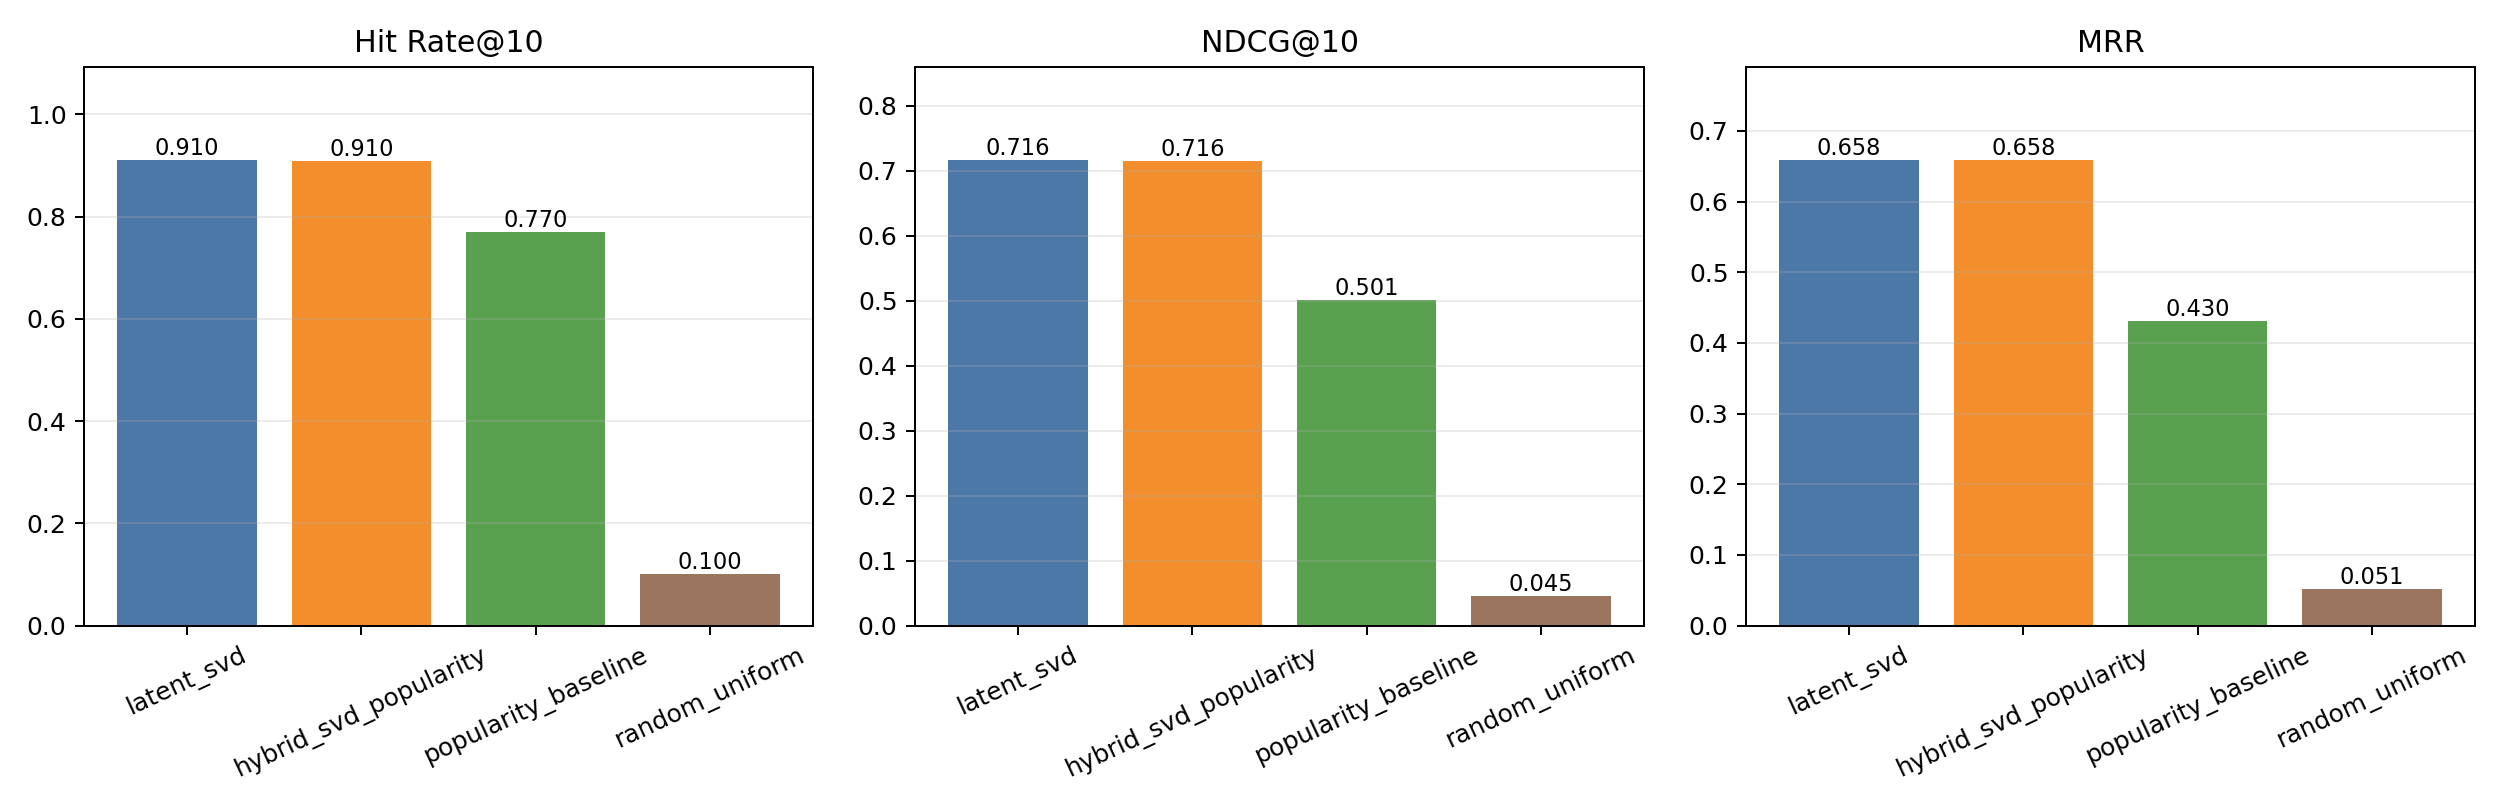

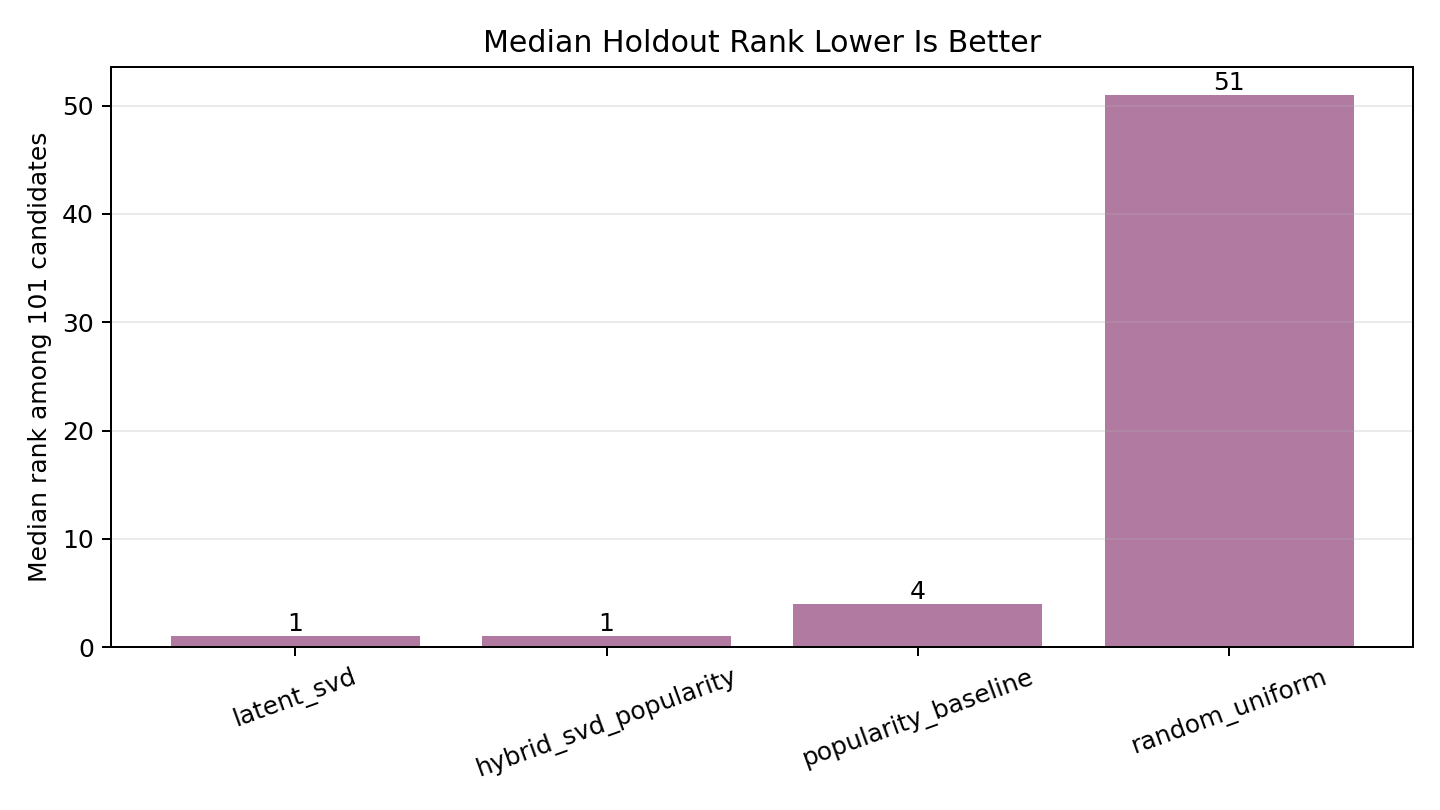

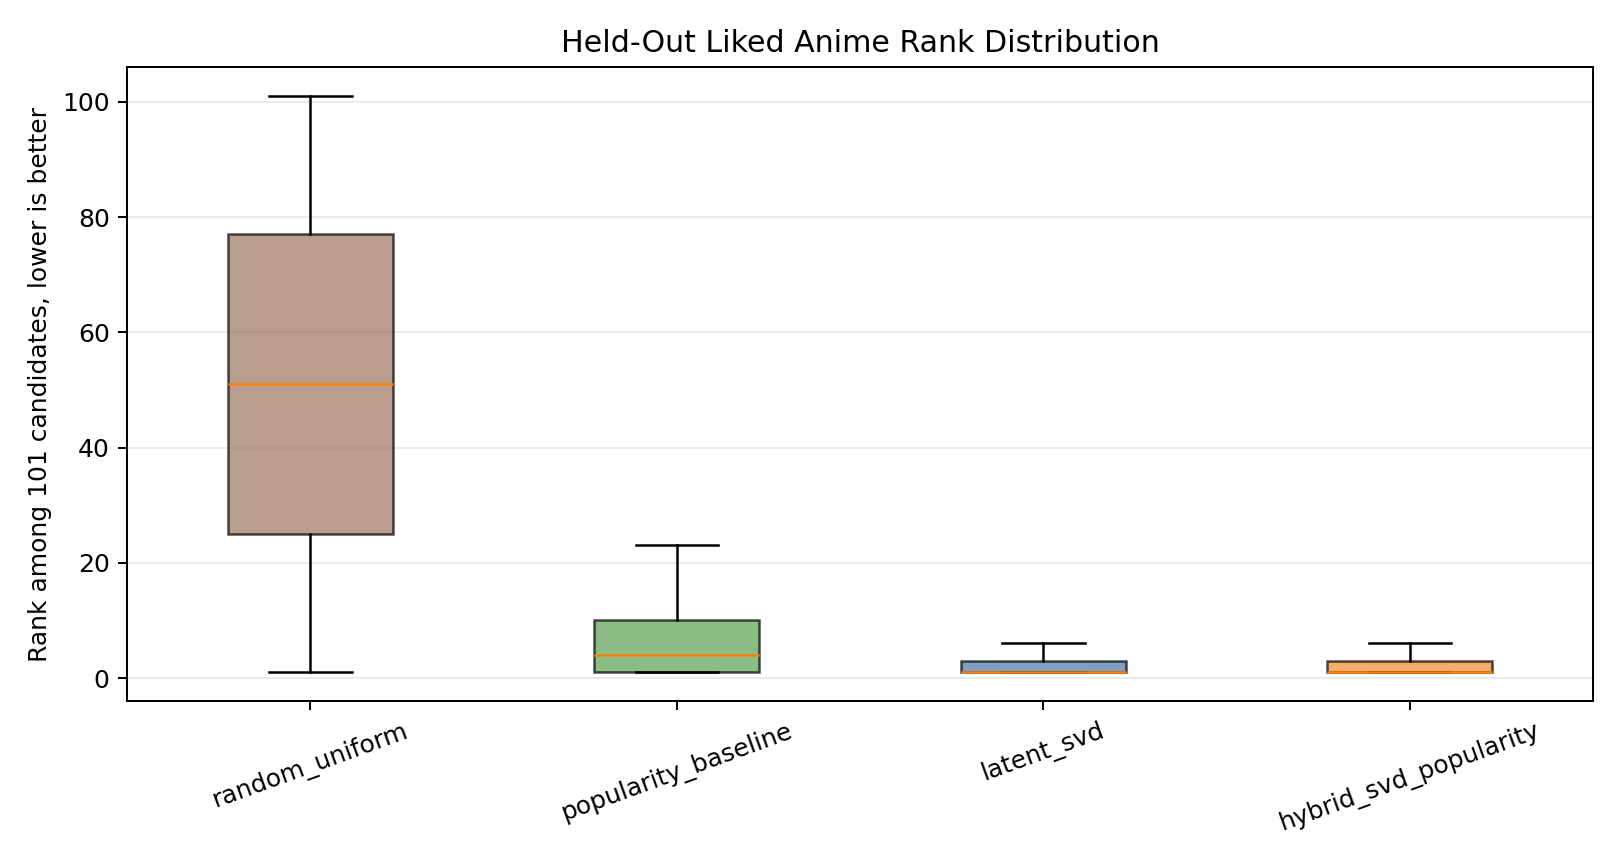

In [6]:
display(Image(filename=str(PLOT_DIR / 'week10_metric_comparison.png')))
display(Image(filename=str(PLOT_DIR / 'week10_median_rank.png')))
display(Image(filename=str(PLOT_DIR / 'week10_rank_distribution_by_method.png')))


## Discovery-Quality Metrics

Accuracy is not the only product goal. Coverage, novelty, and genre diversity show whether a method is only repeating famous anime or actually expanding the discovery surface. These are interpreted beside Hit@10, not instead of it.


In [7]:
metrics[['method', 'hit_rate_at_10', 'coverage_at_10', 'unique_recommended_at_10', 'mean_novelty_at_10', 'mean_unique_genres_at_10', 'mean_genre_diversity_ratio_at_10']]


,method,hit_rate_at_10,coverage_at_10,unique_recommended_at_10,mean_novelty_at_10,mean_unique_genres_at_10,mean_genre_diversity_ratio_at_10
0,latent_svd,0.910200,0.517778,4762,0.275185,14.647733,0.316317
1,hybrid_svd_popularity,0.909600,0.431336,3967,0.256827,14.766467,0.313343
2,popularity_baseline,0.769867,0.203110,1868,0.201700,15.106600,0.306847
3,random_uniform,0.100333,1.000000,9197,0.577695,13.216800,0.389656


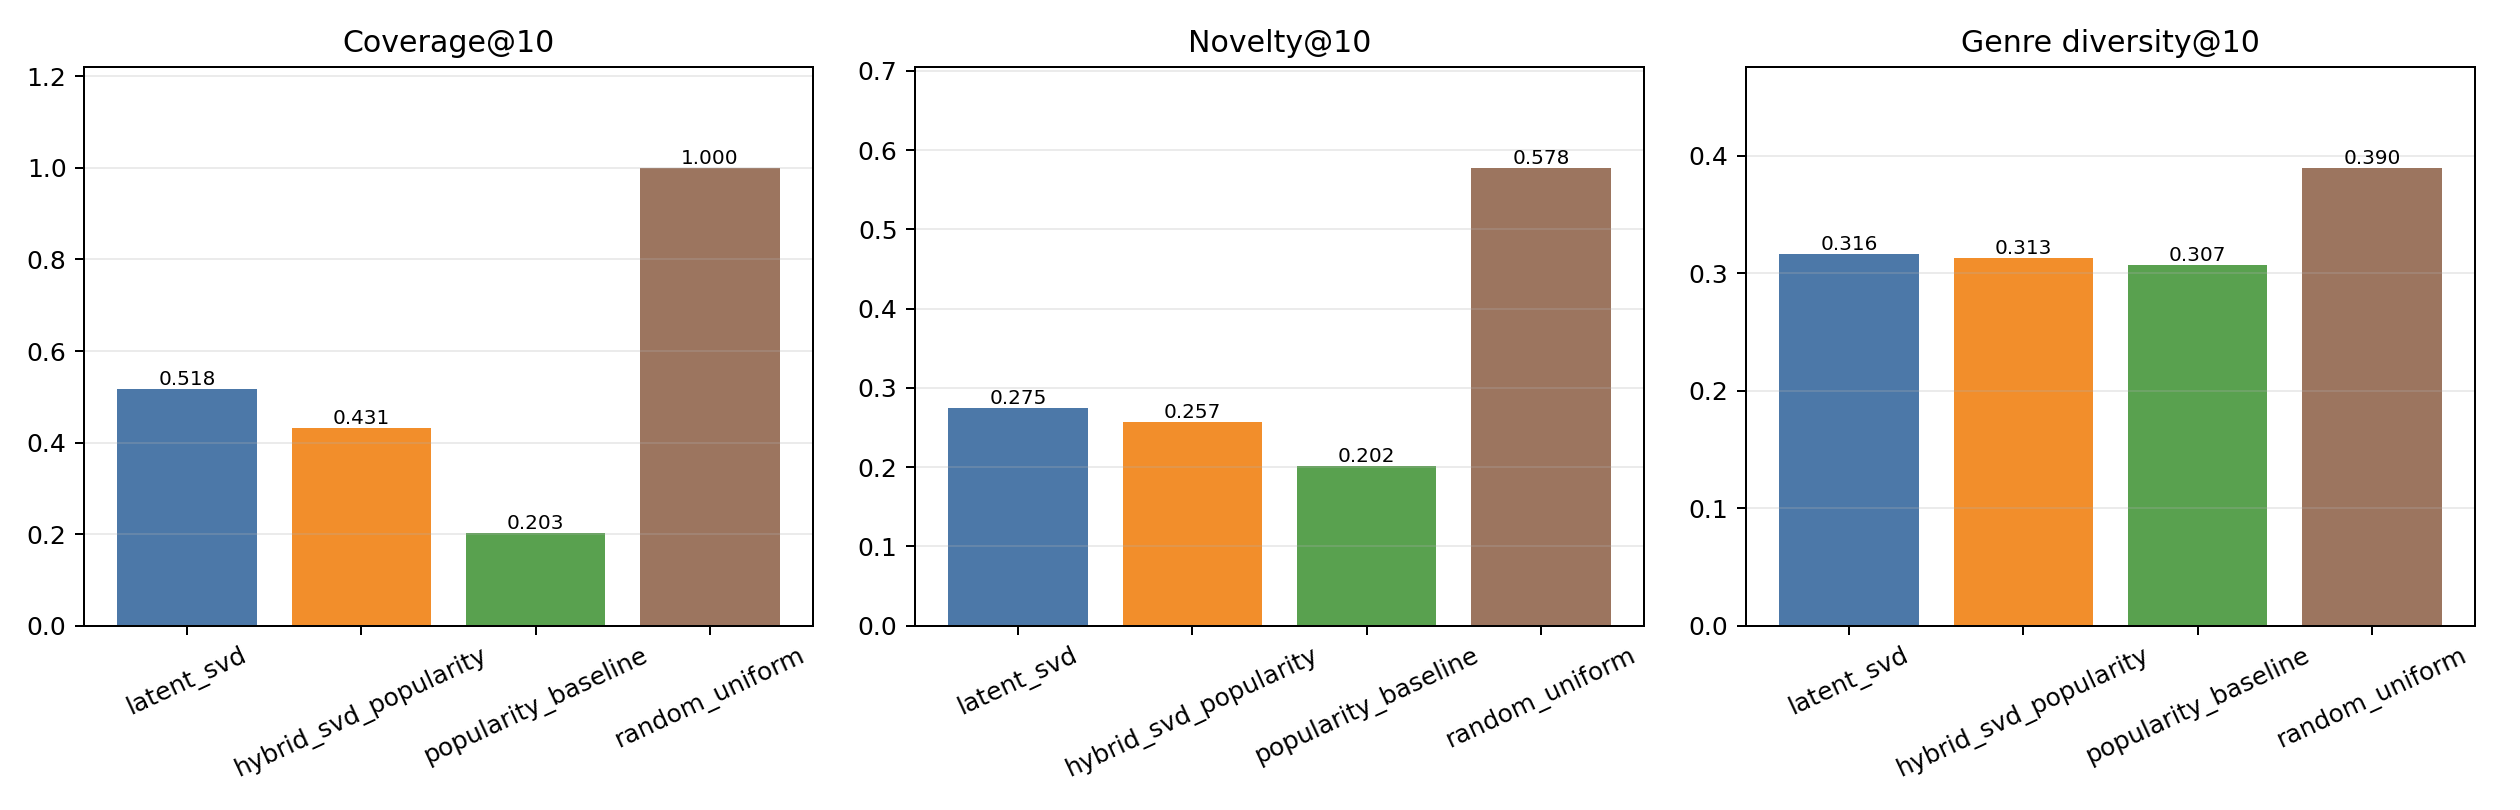

In [8]:
display(Image(filename=str(PLOT_DIR / 'week10_discovery_metrics.png')))


## Results by User Level

The profile-band split is important for interpretation. Newcomers and Casual Viewers benefit strongly from popularity and common taste neighborhoods. Regular and Dedicated fans are well served by collaborative SVD. Veteran Fans and Completionists are smaller groups and are harder because many obvious recommendations are likely already known.

This is why the final product should not only optimize Hit@10. Dense-profile users need novelty, graph-aware exploration, and long-tail coverage, even when exact held-out recovery becomes harder.


In [9]:
level_metrics

,user_level,method,evaluated_users,median_profile_size,hit_rate_at_10,ndcg_at_10,mean_reciprocal_rank,median_rank,mean_rank
0,Newcomer,hybrid_svd_popularity,1726,11.0,0.880070,0.717285,0.669233,1.0,7.973928
1,Newcomer,latent_svd,1726,11.0,0.869061,0.712920,0.666227,1.0,10.516802
2,Newcomer,popularity_baseline,1726,11.0,0.819815,0.565996,0.496162,3.0,6.675550
3,Newcomer,random_uniform,1726,11.0,0.109502,0.047292,0.052006,49.0,50.018540
4,Casual Viewer,hybrid_svd_popularity,2773,34.0,0.932925,0.761454,0.709084,1.0,4.274793
5,Casual Viewer,latent_svd,2773,34.0,0.928237,0.759869,0.708202,1.0,5.233682
6,Casual Viewer,popularity_baseline,2773,34.0,0.807429,0.542063,0.469897,3.0,6.670754
7,Casual Viewer,random_uniform,2773,34.0,0.096646,0.043765,0.050941,51.0,50.821493
8,Explorer,hybrid_svd_popularity,3323,72.0,0.920253,0.738679,0.684104,1.0,4.608185
9,Explorer,latent_svd,3323,72.0,0.922660,0.739205,0.683470,1.0,5.412278


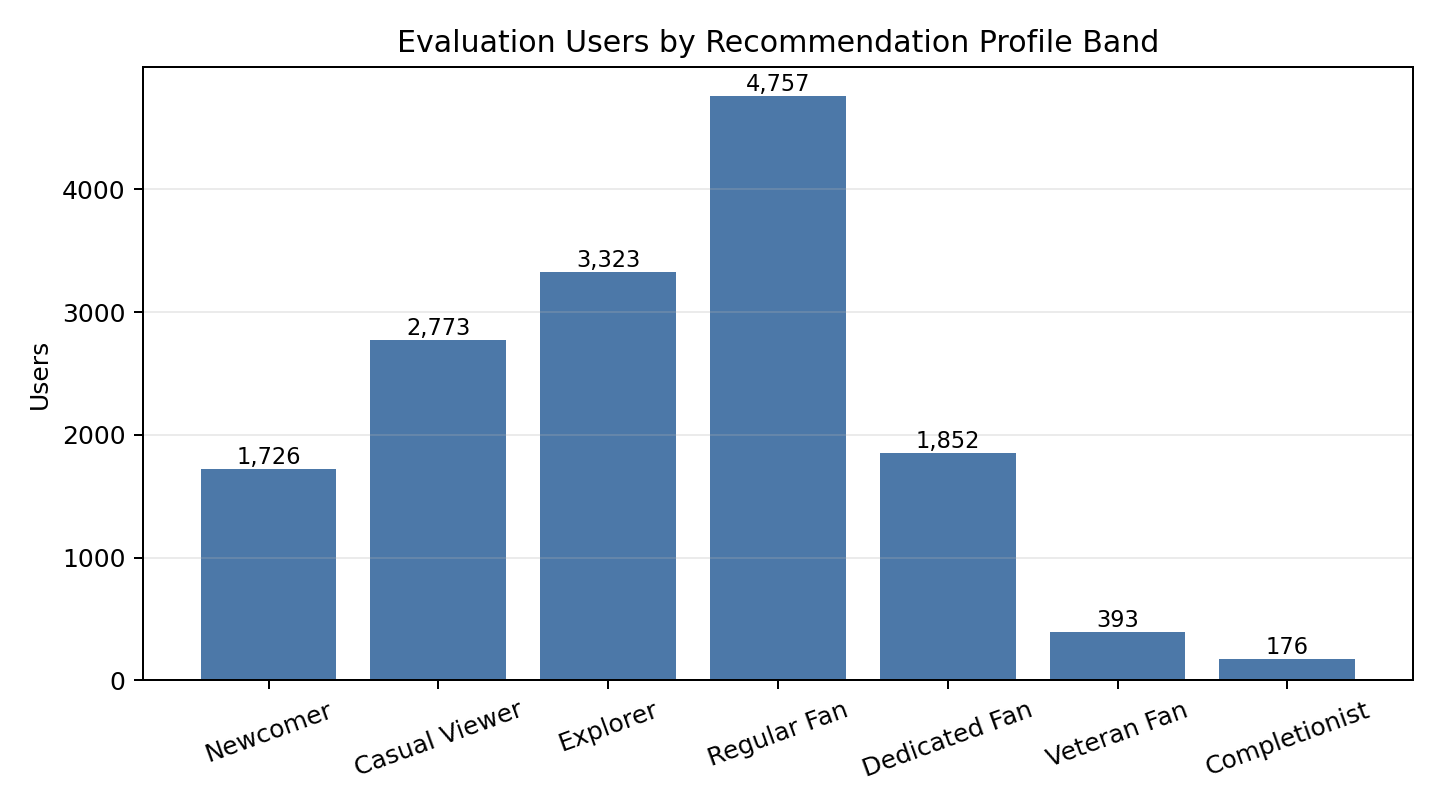

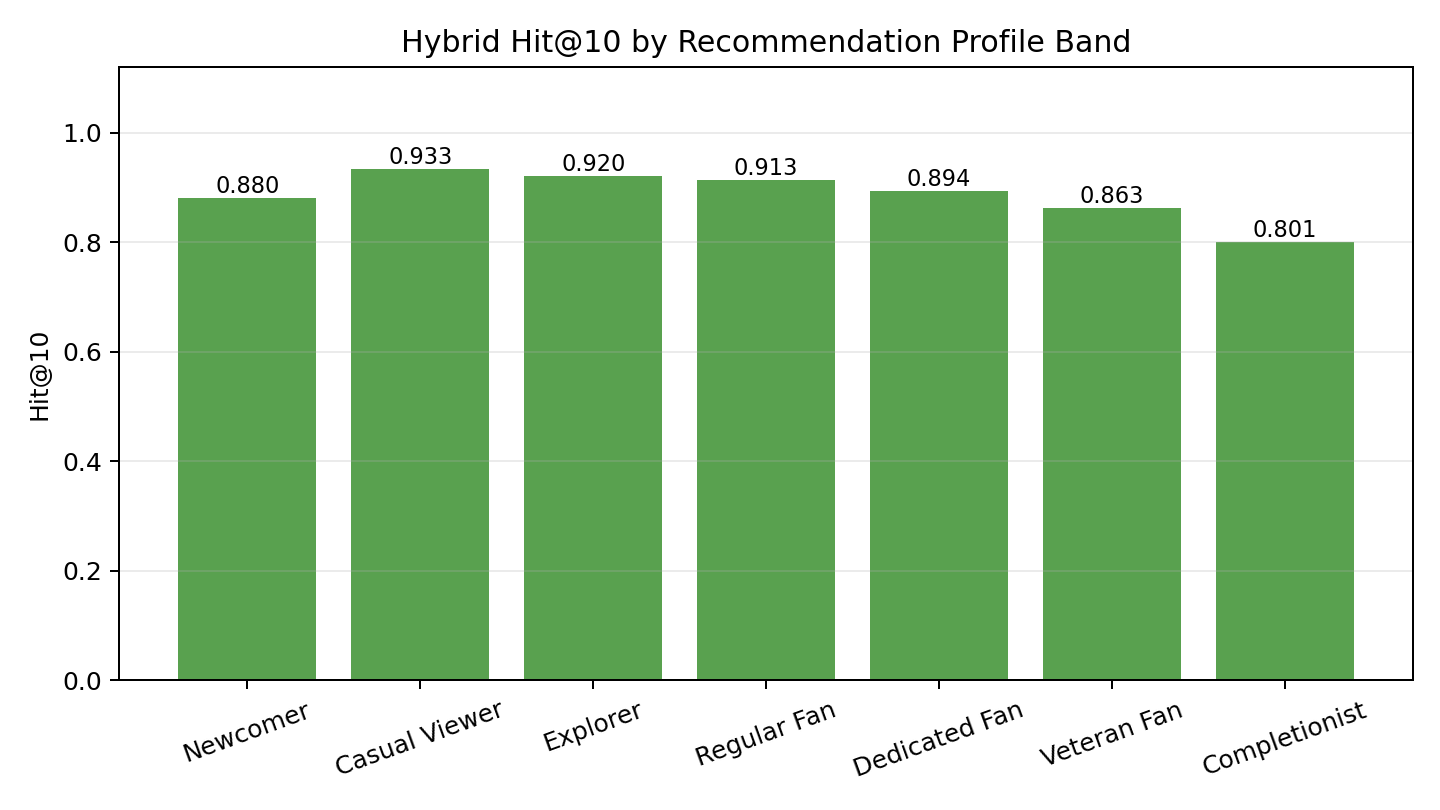

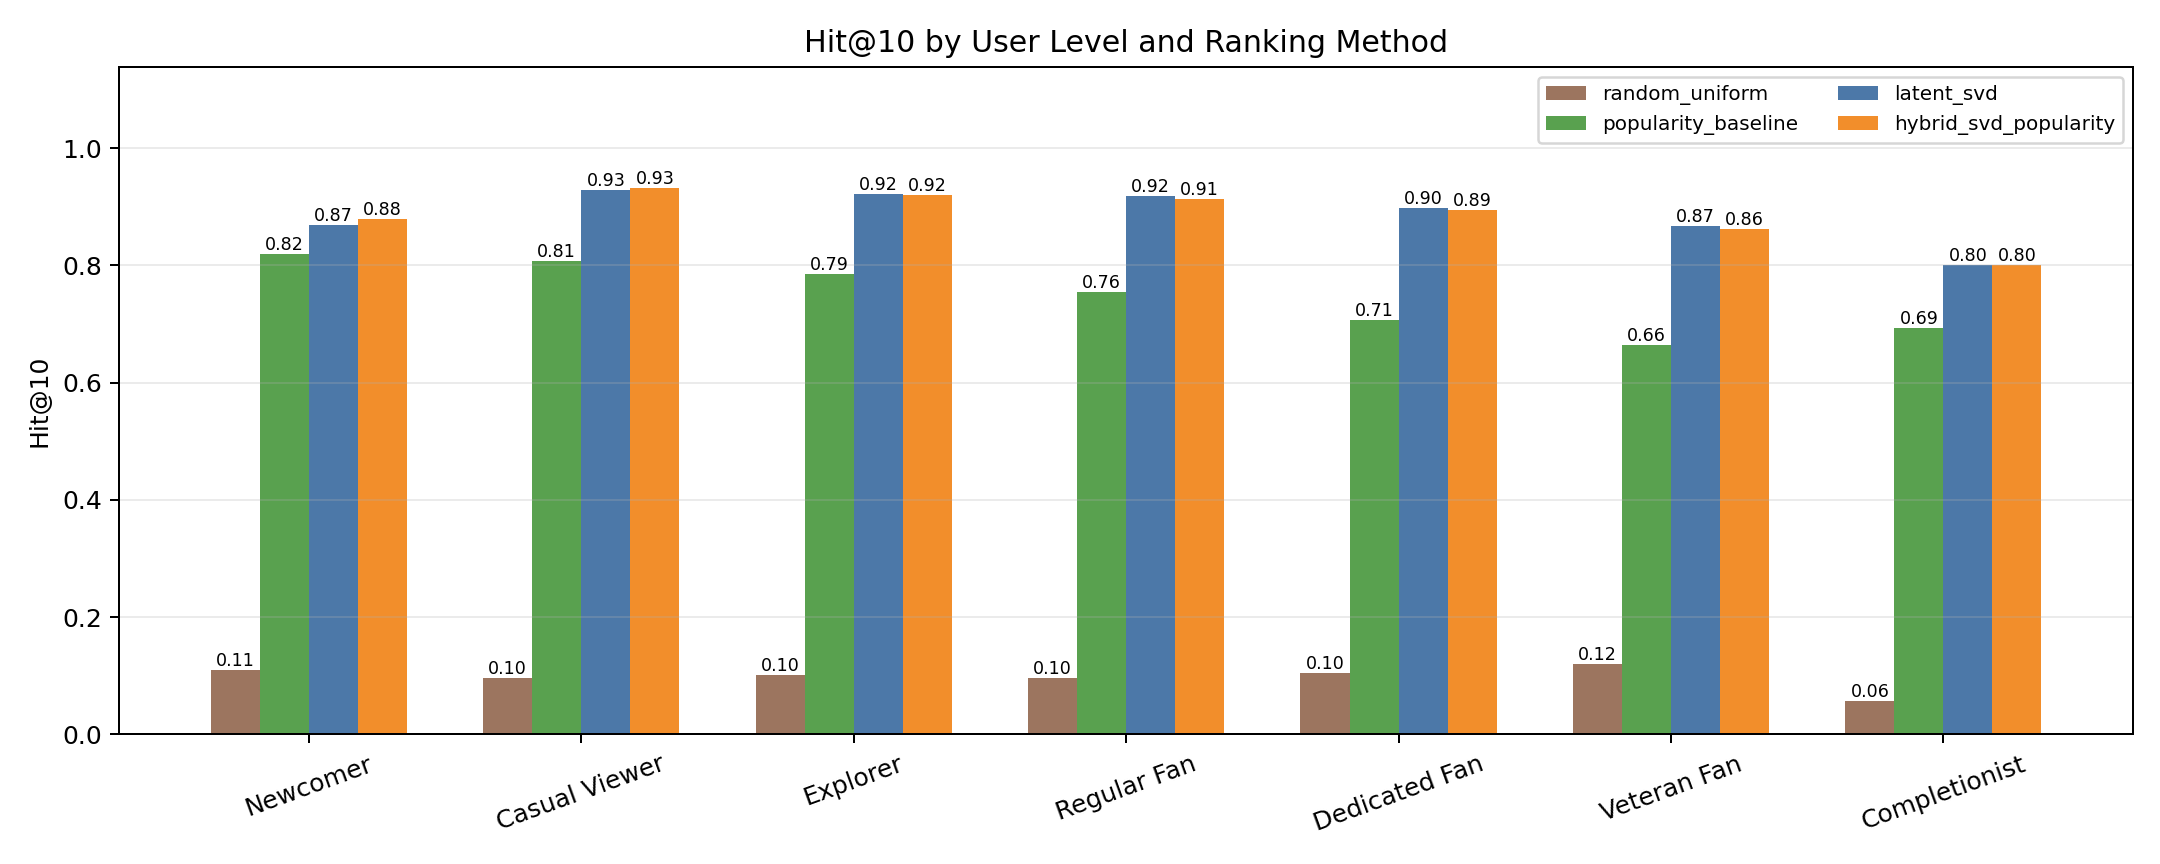

In [10]:
display(Image(filename=str(PLOT_DIR / 'week10_user_level_distribution.png')))
display(Image(filename=str(PLOT_DIR / 'week10_hit_at_10_by_user_level.png')))
display(Image(filename=str(PLOT_DIR / 'week10_method_hit_by_user_level.png')))


## Newcomer Entry-Point Candidates

For Newcomers, the system should not immediately behave like a pure collaborative recommender. The generated entry-point list filters out explicit entries and obvious continuation entries, then ranks high-score, high-engagement, shorter or medium-length entry points. This is an onboarding candidate pool, not the final personalized list.

This is the Week 8 content-based idea in product form: when behavior is missing, use item metadata and defensible filters rather than pretending the user has a collaborative profile.


In [11]:
beginner_candidates.head(25)

,mal_id,title,type,score,members,episodes,duration,total_watch_minutes,aired_year,genres,demographics,rating,beginner_entry_score,why_entry_level
0,52991,Sousou no Frieren,TV,9.26,1456504,28.0,24.0,672.0,2023.0,Adventure|Award Winning|Drama|Fantasy|Action|C...,Shounen,PG-13 - Teens 13 or older,0.780420,high-score popular short/medium-length series
1,9253,Steins;Gate,TV,9.07,2822509,24.0,24.0,576.0,2011.0,Drama|Sci-Fi|Suspense|Comedy|Romance,Seinen,PG-13 - Teens 13 or older,0.764050,high-score popular short/medium-length series
2,28851,Koe no Katachi,Movie,8.93,2627641,1.0,130.0,130.0,2016.0,Award Winning|Drama|Romance,Shounen,PG-13 - Teens 13 or older,0.748618,high-score popular movie; low commitment
3,32281,Kimi no Na wa.,Movie,8.82,3037822,1.0,106.0,106.0,2016.0,Award Winning|Drama|Sci-Fi|Comedy|Romance|Slic...,NaN,PG-13 - Teens 13 or older,0.740506,high-score popular movie; low commitment
4,5114,Fullmetal Alchemist: Brotherhood,TV,9.11,3696136,64.0,24.0,1536.0,2009.0,Action|Adventure|Drama|Fantasy|Sci-Fi|Comedy,Shounen,R - 17+ (violence & profanity),0.736388,high-score popular short/medium-length series
5,16498,Shingeki no Kyojin,TV,8.57,4377647,25.0,24.0,600.0,2013.0,Action|Award Winning|Drama|Suspense|Sci-Fi|Fan...,Shounen,R - 17+ (violence & profanity),0.715103,high-score popular short/medium-length series
6,37521,Vinland Saga,TV,8.78,1833638,24.0,24.0,576.0,2019.0,Action|Adventure|Drama,Seinen,R - 17+ (violence & profanity),0.700159,high-score popular short/medium-length series
7,33352,Violet Evergarden,TV,8.69,2005781,13.0,24.0,312.0,2018.0,Drama|Action|Sci-Fi|Romance|Slice of Life,Seinen,PG-13 - Teens 13 or older,0.687728,high-score popular short/medium-length series
8,1535,Death Note,TV,8.62,4314806,37.0,23.0,851.0,2006.0,Supernatural|Suspense|Fantasy|Romance|Mystery,Shounen,R - 17+ (violence & profanity),0.684968,high-score popular short/medium-length series
9,30276,One Punch Man,TV,8.47,3530194,12.0,24.0,288.0,2015.0,Action|Comedy|Gourmet|Sci-Fi|Sports,Seinen,R - 17+ (violence & profanity),0.684897,high-score popular short/medium-length series


## Example Recommendation Cases

The examples table stores held-out titles, the user's training titles, and the hybrid top-10 candidate list. These examples are useful for qualitative defense: the metric says how often the system works, but examples show whether the output feels like anime discovery rather than arbitrary IDs.

In [12]:
examples[['case_type', 'user_level', 'profile_size', 'holdout_title', 'popularity_rank', 'latent_svd_rank', 'hybrid_rank', 'train_titles', 'hybrid_top10_titles']].head(20)

,case_type,user_level,profile_size,holdout_title,popularity_rank,latent_svd_rank,hybrid_rank,train_titles,hybrid_top10_titles
0,hybrid_win,Casual Viewer,23,One Piece Movie 01,12,4,4,Fullmetal Alchemist | Mononoke Hime | Shingets...,Chobits | Pokemon Movie 01: Mewtwo no Gyakushu...
1,both_hit,Casual Viewer,49,Toradora!,1,2,2,Shinseiki Evangelion | Shinseiki Evangelion Mo...,Tokyo Ghoul √A | Toradora! | Youkoso Jitsuryok...
2,both_hit,Explorer,97,Sword Art Online Alternative: Gun Gale Online,6,2,2,Death Note | Special A | Soul Eater | Kuroshit...,Shingeki no Kyojin Season 2 | Sword Art Online...
3,both_hit,Dedicated Fan,324,Aldnoah.Zero,3,3,3,Trigun | Eyeshield 21 | Rurouni Kenshin: Meiji...,Danshi Koukousei no Nichijou | Strike the Bloo...
4,both_hit,Regular Fan,135,Kill la Kill,1,1,1,Shinseiki Evangelion | Shinseiki Evangelion Mo...,Kill la Kill | One Punch Man: Road to Hero | S...
5,hybrid_win,Explorer,63,Mizu no Kotoba,33,7,8,Howl no Ugoku Shiro | Perfect Blue | One Piece...,Made in Abyss Movie 3: Fukaki Tamashii no Reim...
6,both_hit,Regular Fan,129,Darker than Black: Ryuusei no Gemini,4,2,2,Cowboy Bebop | Hachimitsu to Clover | Aa! Mega...,School Rumble | Darker than Black: Ryuusei no ...
7,both_hit,Dedicated Fan,457,Ghost Hunt,7,7,7,Eyeshield 21 | Hungry Heart: Wild Striker | Na...,Vampire Knight Guilty | Darling in the FranXX ...
8,both_hit,Dedicated Fan,342,JoJo no Kimyou na Bouken (TV),2,1,1,Shingetsutan Tsukihime | Tenjou Tenge | Sen to...,JoJo no Kimyou na Bouken (TV) | Kami no Tou | ...
9,both_hit,Regular Fan,197,Sekirei: Pure Engagement,5,3,3,Cowboy Bebop | Naruto | Shinseiki Evangelion |...,K-On! | School Days | Sekirei: Pure Engagement...


## MyList Demonstration: Naive vs Guarded

The first MyList table is intentionally the naive hybrid output. It uses scored titles rated at least 7 as positive seed evidence, excludes every anime already present in the list, and ranks unseen candidates. This is useful because it exposes product failures: it can recommend a sequel after a disliked prerequisite, a second season before season one, or side content without the parent.

The guarded comparison underneath is a Week 12 preview. It applies relation and status rules after ranking: block summaries/recaps of known titles, block missing prerequisites, block prerequisites that are only plan-to-watch, block prerequisites rated below 7, and block side/special content unless the parent is liked.


In [13]:
mylist_recommendations[['mal_id', 'title', 'type', 'score', 'relations', 'mylist_hybrid_score']].head(25)


,mal_id,title,type,score,relations,mylist_hybrid_score
0,11979,Mahou Shoujo Madoka★Magica Movie 2: Eien no Mo...,Movie,8.38,Prequel:11977|Sequel:11981,0.653311
1,11977,Mahou Shoujo Madoka★Magica Movie 1: Hajimari n...,Movie,8.22,Sequel:11979,0.650448
2,31765,Sword Art Online Movie: Ordinal Scale,Movie,7.56,Prequel:21881|Sequel:36474,0.568375
3,27787,Nisekoi:,TV,7.34,Prequel:18897|Side Story:32553,0.552839
4,8937,Toaru Majutsu no Index II,TV,7.51,Prequel:4654|Sequel:36432|Side Story:11743,0.542915
5,10379,Natsume Yuujinchou San,TV,8.56,Prequel:5300|Sequel:11665,0.537374
6,36296,Hinamatsuri,TV,8.11,NaN,0.529575
7,11665,Natsume Yuujinchou Shi,TV,8.63,Prequel:10379|Sequel:32983|Side Story:18849|Si...,0.525460
8,15315,Mondaiji-tachi ga Isekai kara Kuru Sou desu yo?,TV,7.40,Sequel:16444,0.518748
9,4898,Kuroshitsuji,TV,7.65,Sequel:6707|Sequel:22145,0.514237


### Guardrail Decisions

These are the highest-ranked naive recommendations that the guardrails block. This turns the bad recommendations into failure analysis instead of hiding them.


In [14]:
mylist_guardrail_block_summary[['block_category', 'blocked_count', 'blocked_pct_of_reviewed']]


,block_category,blocked_count,blocked_pct_of_reviewed
0,summary_or_recap,5,0.054945
1,missing_prerequisite,55,0.604396
2,plan_to_watch_prerequisite,19,0.208791
3,low_rated_prerequisite,8,0.087912
4,side_content_without_liked_parent,24,0.263736
5,any_block,91,0.455000


In [15]:
mylist_guardrail_comparison.query("guardrail_action == 'blocked'")[['raw_rank', 'mal_id', 'title', 'type', 'mylist_hybrid_score', 'guardrail_reason']].head(25)


,raw_rank,mal_id,title,type,mylist_hybrid_score,guardrail_reason
0,1,11979,Mahou Shoujo Madoka★Magica Movie 2: Eien no Mo...,Movie,0.653310,summary/recap of known title 9756 | missing pr...
1,2,11977,Mahou Shoujo Madoka★Magica Movie 1: Hajimari n...,Movie,0.650448,summary/recap of known title 9756
2,3,31765,Sword Art Online Movie: Ordinal Scale,Movie,0.568375,low-rated prerequisite 21881:4
3,4,27787,Nisekoi:,TV,0.552839,prerequisite is only plan-to-watch 18897
7,8,11665,Natsume Yuujinchou Shi,TV,0.525460,missing prerequisite 10379
14,15,24227,Nisekoi OVA,OVA,0.493490,prerequisite is only plan-to-watch 18897 | sid...
17,18,34577,Nanatsu no Taizai: Imashime no Fukkatsu,TV,0.483853,missing prerequisite 31722
19,20,39597,Sword Art Online: Alicization - War of Underworld,TV,0.477456,prerequisite is only plan-to-watch 36474
21,22,32867,Bungou Stray Dogs 2nd Season,TV,0.476418,missing prerequisite 31478
23,24,32902,Mahoutsukai no Yome: Hoshi Matsu Hito,OVA,0.474740,prerequisite is only plan-to-watch 35062 | sid...


### Guarded MyList Recommendations

After the guardrails, relation-valid continuations such as `Toaru Majutsu no Index II` and `Natsume Yuujinchou San` remain, while the obvious failures are removed from the general discovery list.


In [16]:
mylist_guarded_recommendations[['guarded_rank', 'mal_id', 'title', 'type', 'score', 'relations', 'mylist_hybrid_score']].head(25)


,guarded_rank,mal_id,title,type,score,relations,mylist_hybrid_score
0,1,8937,Toaru Majutsu no Index II,TV,7.51,Prequel:4654|Sequel:36432|Side Story:11743,0.542915
1,2,10379,Natsume Yuujinchou San,TV,8.56,Prequel:5300|Sequel:11665,0.537374
2,3,36296,Hinamatsuri,TV,8.11,NaN,0.529575
3,4,15315,Mondaiji-tachi ga Isekai kara Kuru Sou desu yo?,TV,7.40,Sequel:16444,0.518748
4,5,4898,Kuroshitsuji,TV,7.65,Sequel:6707|Sequel:22145,0.514237
5,6,38408,Boku no Hero Academia 4th Season,TV,7.86,Prequel:36456|Sequel:41587|Side Story:39565,0.505019
6,7,585,Mimi wo Sumaseba,Movie,8.23,Spin-Off:597,0.498347
7,8,35838,Shoujo Shuumatsu Ryokou,TV,8.24,NaN,0.495852
8,9,37171,Asobi Asobase,TV,8.19,Sequel:37996,0.494248
9,10,5365,Tsumiki no Ie,Movie,7.99,NaN,0.488940


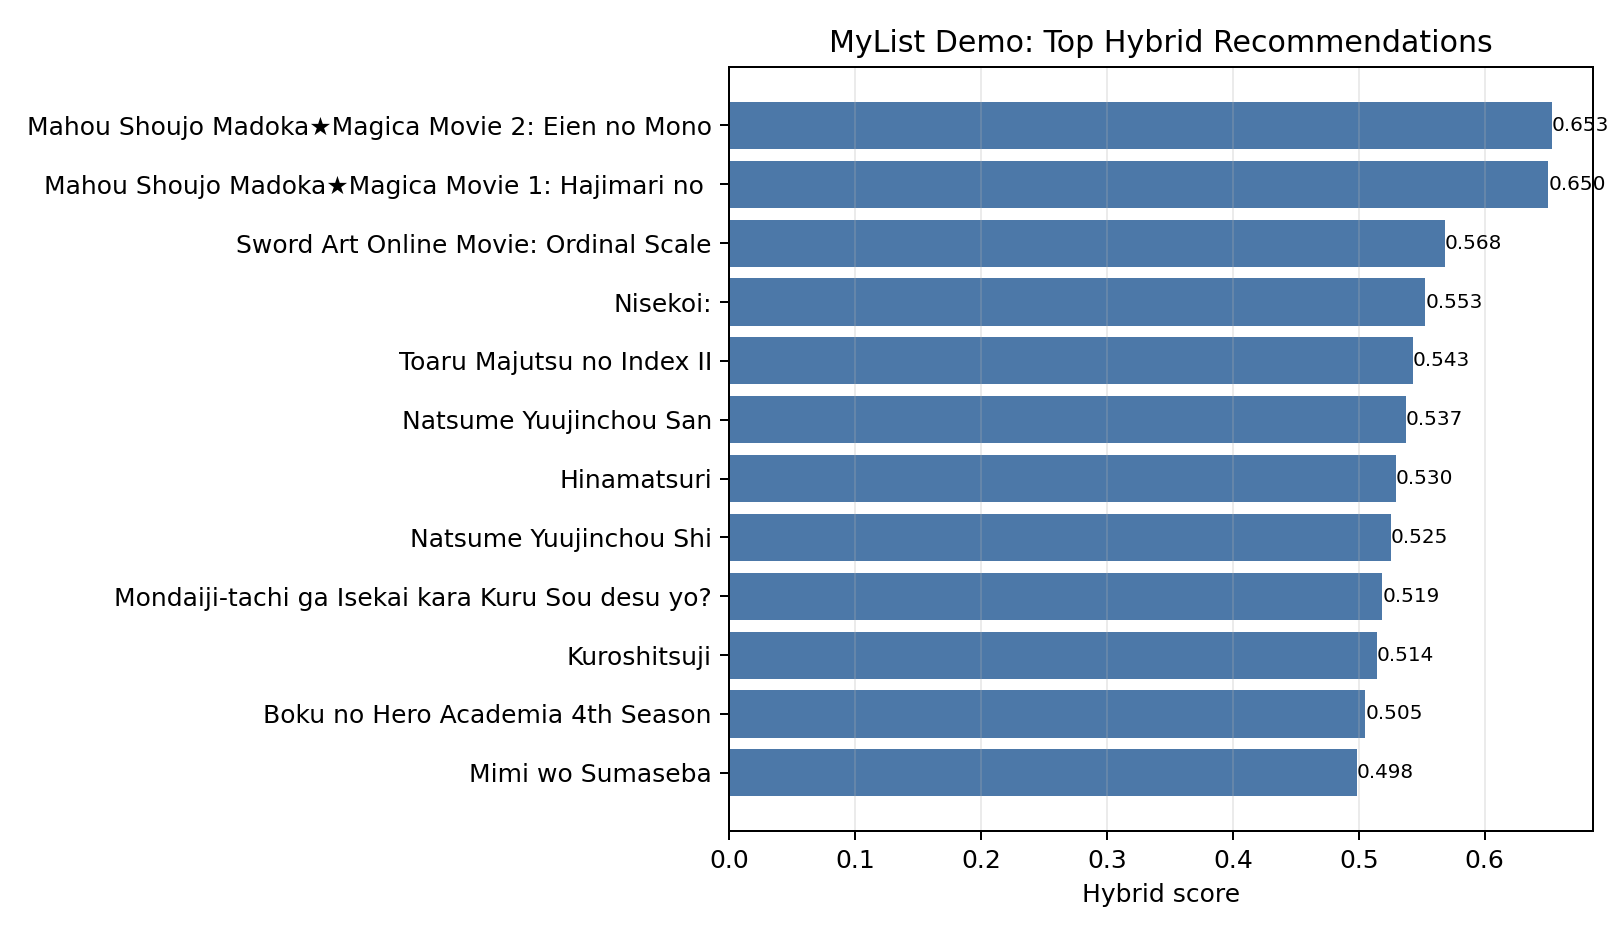

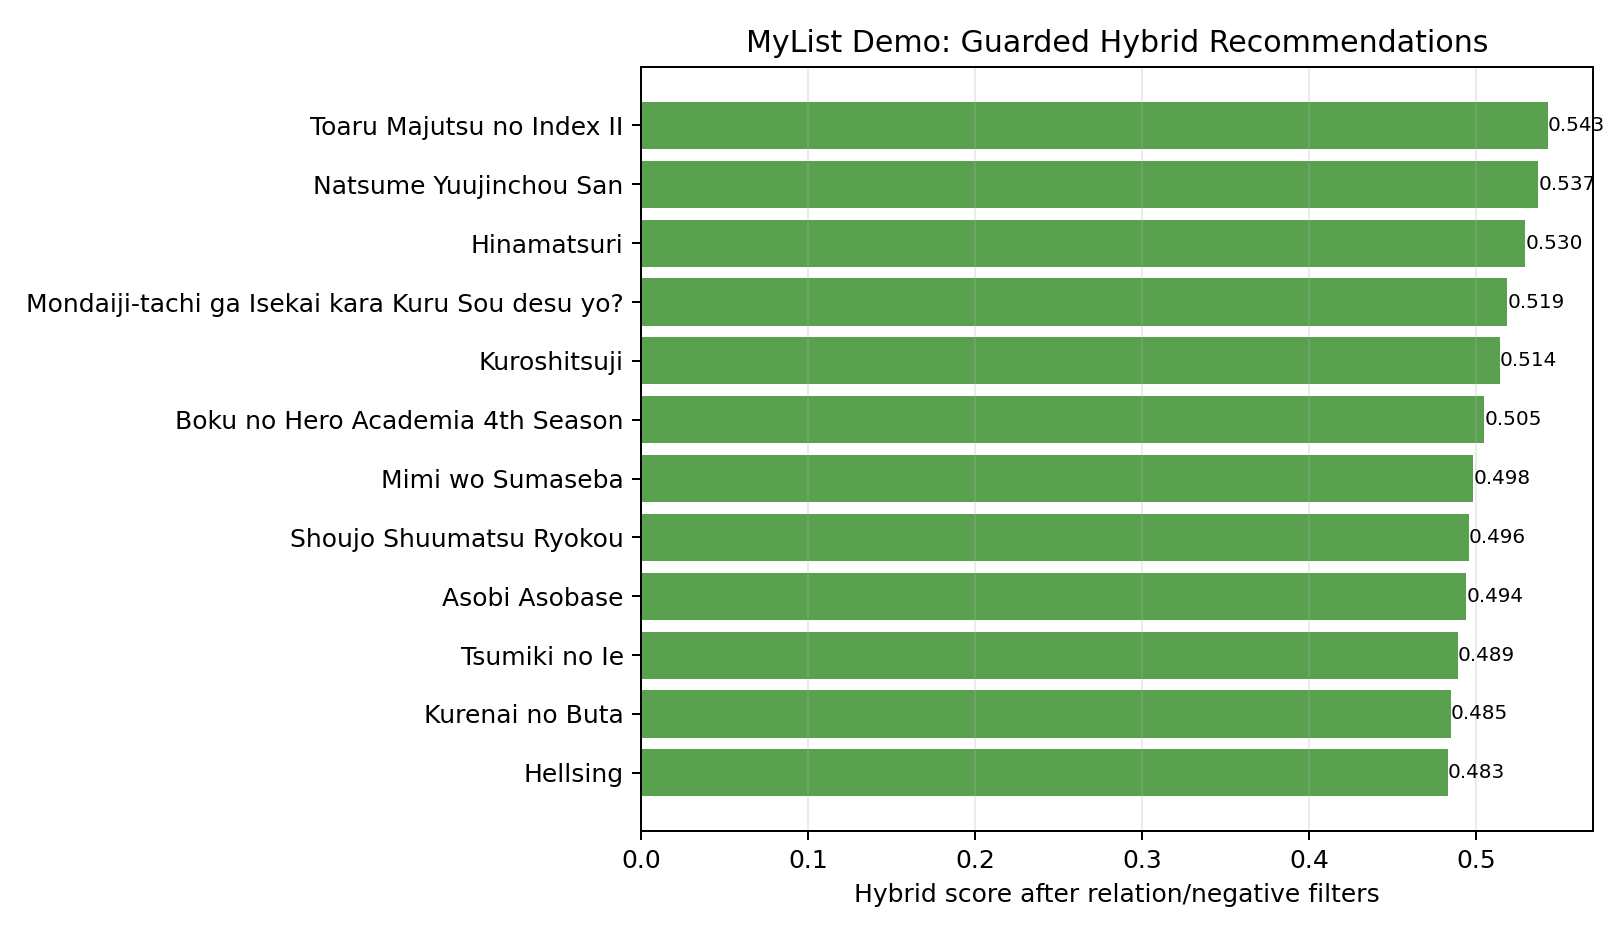

In [17]:
display(Image(filename=str(PLOT_DIR / 'week10_mylist_top_recommendations.png')))
display(Image(filename=str(PLOT_DIR / 'week10_mylist_guarded_top_recommendations.png')))


## Interpretation and Limits

The personalized models beat both the random floor and the popularity baseline, which supports using collaborative information instead of only recommending famous shows. The popularity baseline remains important: anime discourse often concentrates around famous or seasonal titles, so a complex model that cannot beat popularity would not be worth defending.

The evaluation is intentionally conservative in its claims. It does not prove chronological next-watch prediction, and the 100-negative sampled setting is easier than ranking the entire catalog. It also uses the 2020 ratings dataset while a more current user-rating layer is still being collected for a later deliverable.

The final recommender should combine four components: user controls, collaborative ranking, content/genre constraints, and graph relations. Relation edges should handle sequels and franchise navigation so the general recommender does not awkwardly suggest season three before season one. The next interaction-layer upgrade should also use list status: dropped titles should usually be exclusion evidence, while scored watching/on-hold titles can still be taste evidence.


## Reproducibility

Run the Week 10 pipeline from the repository root with:

```bash
python src/08_run_week10_recommendation.py
```

Main outputs are saved in `artifacts/recommendation/` and `artifacts/plots/week10/`, including the evaluation metrics, user-level metrics, beginner entry candidates, MyList example, Champux profile summary, and plots.
